In [1]:
import pandas as pd
import requests
import io
import missingno as msno

In [2]:
pd.set_option('display.max_rows', None)

In [3]:
URL = "https://data.wa.gov/resource/f6w7-q2d2.csv"

LIMIT = 100_000
OFFSET = 0

chunks = []

with requests.Session() as session:
    while True:
        response = session.get(
            URL,
            params={
                "$limit": LIMIT,
                "$offset": OFFSET,
            },
            timeout=600,
        )
        response.raise_for_status()

        chunk = pd.read_csv(io.BytesIO(response.content))

        if chunk.empty:
            print("No more rows to download.")
            break

        chunks.append(chunk)

        OFFSET += len(chunk)

        print(f"Retrieved {OFFSET:,} rows")

        if len(chunk) < LIMIT:
            print("No more rows to download.")
            break

df = pd.concat(chunks, ignore_index=True)

Retrieved 100,000 rows
Retrieved 200,000 rows
Retrieved 294,193 rows
No more rows to download.


<Axes: >

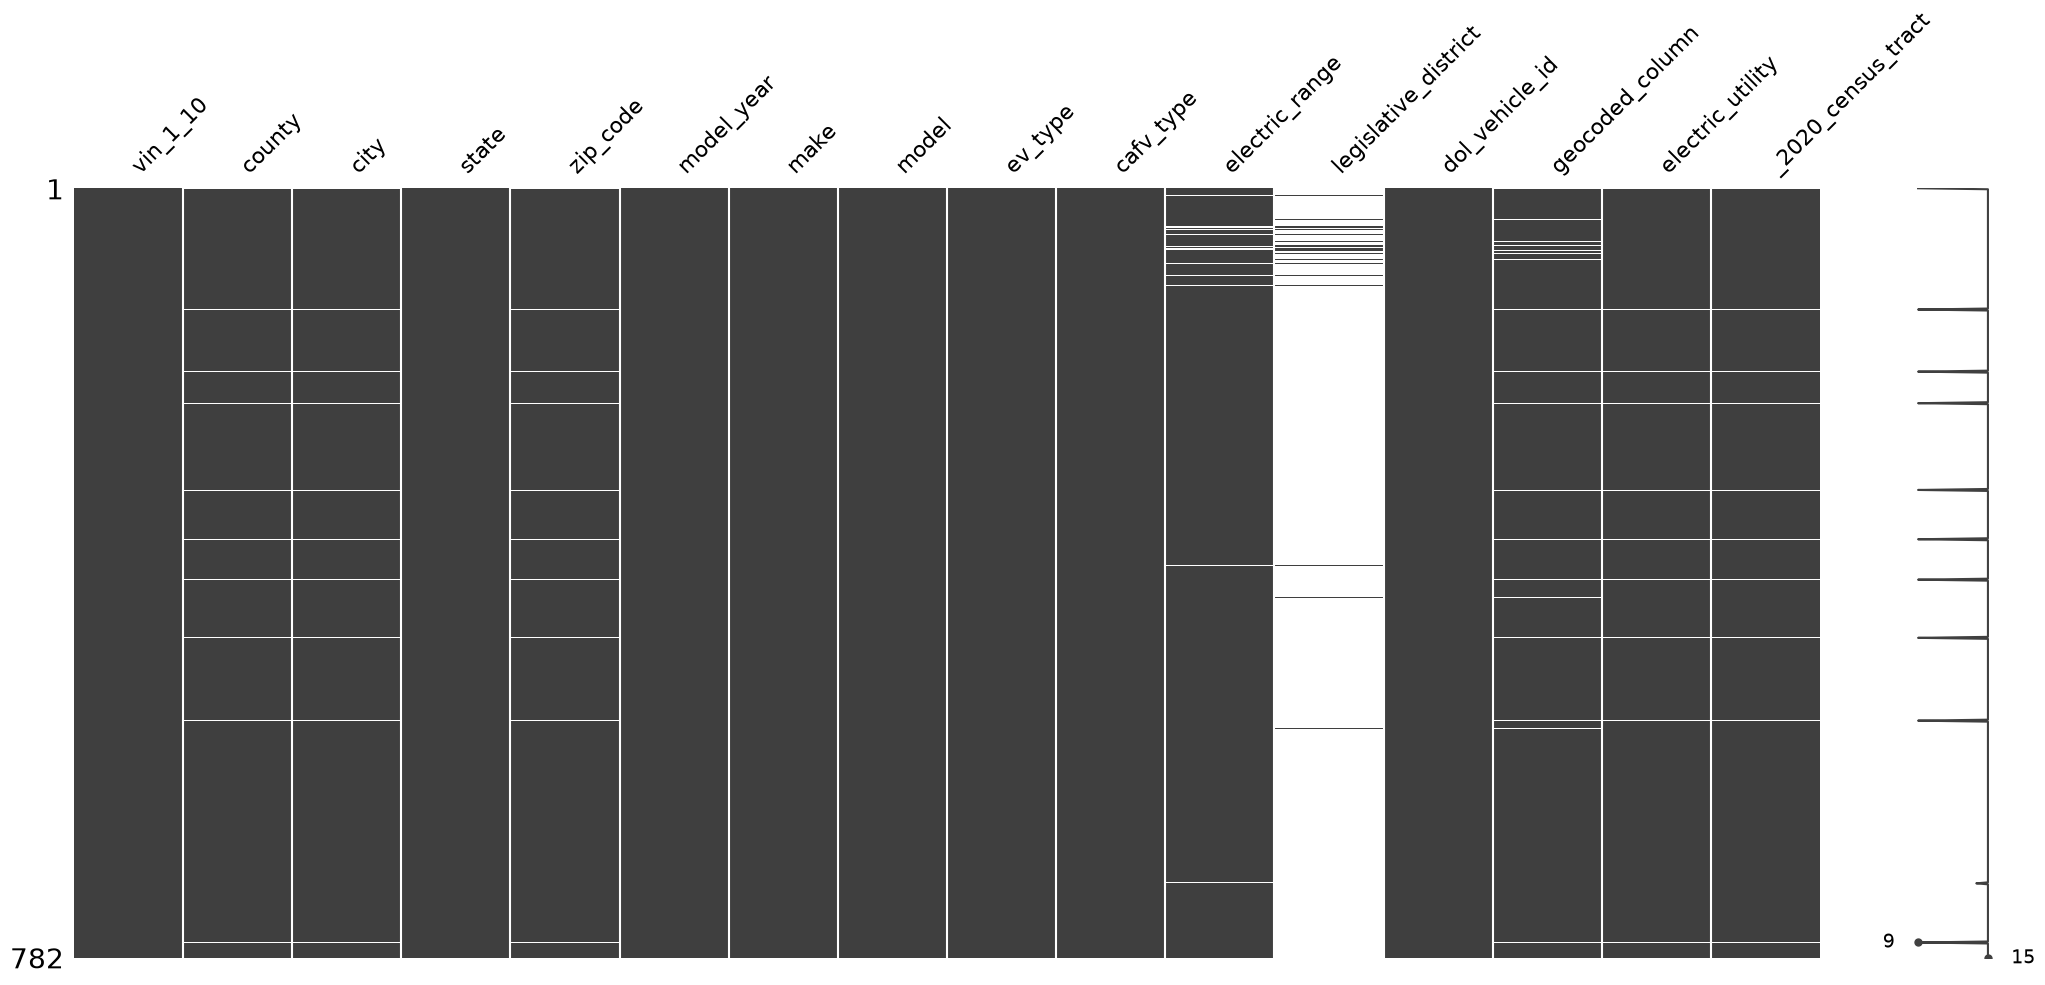

In [15]:
msno.matrix(df[df.isnull().any(axis=1)])

In [ ]:
df[df.isnull().any(axis=1)]

In [14]:
df.isnull().sum()

vin_1_10                  0
county                   10
city                     10
state                     0
zip_code                 10
model_year                0
make                      0
model                     0
ev_type                   0
cafv_type                 0
electric_range           13
legislative_district    762
dol_vehicle_id            0
geocoded_column          18
electric_utility         10
_2020_census_tract       10
dtype: int64

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294193 entries, 0 to 294192
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   vin_1_10              294193 non-null  str    
 1   county                294183 non-null  str    
 2   city                  294183 non-null  str    
 3   state                 294193 non-null  str    
 4   zip_code              294183 non-null  float64
 5   model_year            294193 non-null  int64  
 6   make                  294193 non-null  str    
 7   model                 294193 non-null  str    
 8   ev_type               294193 non-null  str    
 9   cafv_type             294193 non-null  str    
 10  electric_range        294180 non-null  float64
 11  legislative_district  293431 non-null  float64
 12  dol_vehicle_id        294193 non-null  int64  
 13  geocoded_column       294175 non-null  str    
 14  electric_utility      294183 non-null  str    
 15  _2020_censu

In [11]:
df.duplicated(subset=['vin_1_10']).sum()

np.int64(276125)